<>:77: SyntaxWarning: invalid escape sequence '\s'
<>:77: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_7416/2022023589.py:77: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


Processing for Rigidity = 2 EV...
Using npatch = 93

Processing for Rigidity = 8 EV...
Using npatch = 93

Creating side-by-side skymaps...


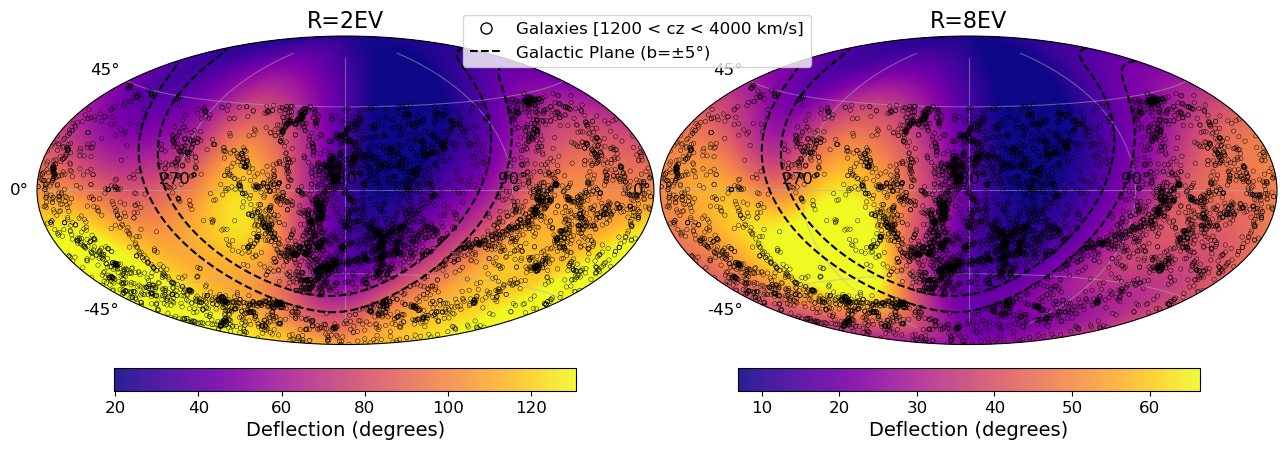


Creating side-by-side correlation plots...


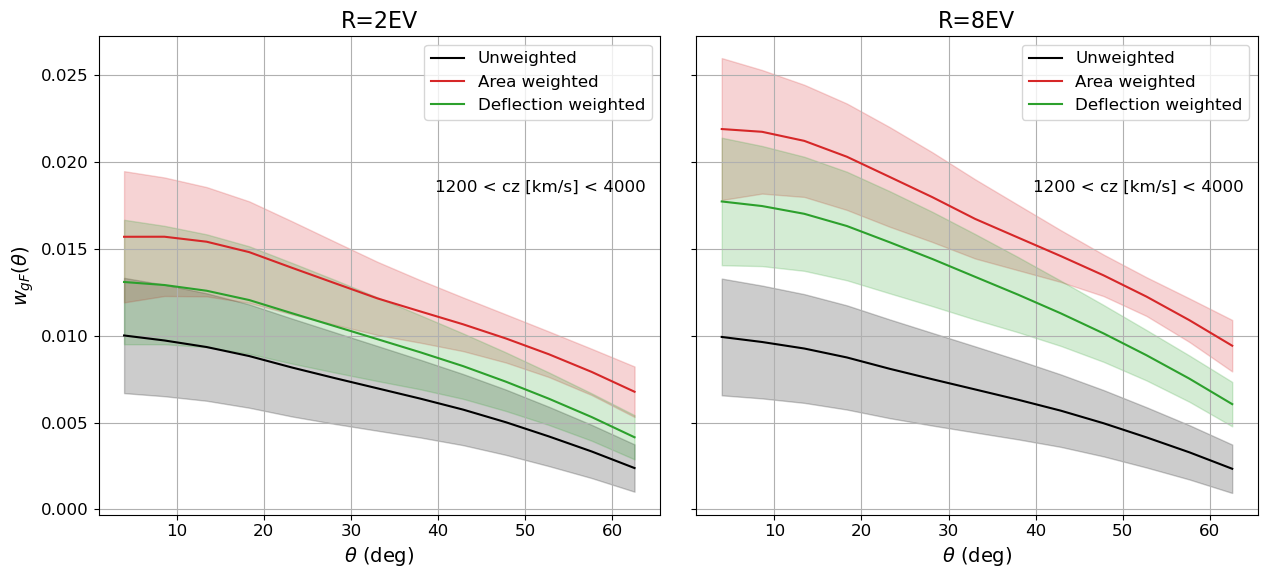

In [6]:
"""
Comparar R=2 y R=8 en el mismo plot - Modified for side-by-side comparison

##########################################

Cleaned and modularized galaxy-flux correlation script with optional galaxy weights
(applies JF12 deflection map-derived weights to galaxies only).

Usage:
  - Edit file paths at the top if needed.
  - Run in an environment with treecorr, healpy, astropy, pandas, numpy, matplotlib.

Notes:
  - The `compute_weight_from_deflection` function is a placeholder: replace with
    the exact mapping you want from JF12 deflection to galaxy weight.
  - This script uses a deterministic subset of randoms and a fixed set of
    patch_centers so weighted/unweighted runs are consistent.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import healpy as hp
import treecorr
from astropy.io import ascii


# --------------------------- Configuration ---------------------------
class Config:
    """Configuration parameters for the analysis."""
    GLADE_FILE = "../data/GLADE_zhelio_lt0.1_dL_lt300.txt"
    #DEFL_FILE = "../data/deflexionZ2E510_R2_ra_dec_deg.txt"
    DEFL_FILE = "../data/deflexiones_R2R5R8_final.txt"
    FLUX_FILE = "../data/Auger/flux_a8_lb.dat"
    PLOTS_DIR = "../plots"
    
    FWHM_DEG = 30.0  # smoothing for deflection map
    RIGIDITY = 5  # default rigidity for deflection map
    N_RAND_PER_GAL = 100 # number of randoms per galaxy
    MIN_CZ = 1200 
    MAX_CZ = 4000
    MK_CUT = -18.0
    MAX_DEC = 45.0
    
    # TreeCorr configuration (NK correlation)
    TC_CONFIG = {
        "min_sep": 1,
        "max_sep": 65.,
        "nbins": 13,
        "sep_units": 'degree',
        "bin_type": 'Linear',
        "brute": False,
        "metric": 'Arc',
        "var_method": 'jackknife',
        "cross_patch_weight": 'simple'
    }


# --------------------------- Data Loading Functions ---------------------------
def read_GLADE(cols_to_use, cz_min=Config.MIN_CZ, dL_max=200, filename=Config.GLADE_FILE):
    """Read and filter GLADE catalog."""
    from get_masks import get_milkyway_mask
    
    c = 299792.458
    chunksize = 200_000
    
    with open(filename, 'r') as f:
        header = f.readline().lstrip('#').split()
    
    filtered_chunks = []
    
    for chunk in pd.read_csv(
            filename,
            sep='\s+',
            names=header,
            usecols=cols_to_use,
            skiprows=1,
            chunksize=chunksize):
        
        chunk = chunk[chunk["dist_flag"] != 0]
        chunk["cz"] = c * chunk["z_cmb"]
        chunk = chunk[(chunk["cz"] > cz_min) & (chunk["d_L"] < dL_max)]
        mask = np.isfinite(chunk["B"]) & np.isfinite(chunk["d_L"]) & \
               np.isfinite(chunk["RA"]) & np.isfinite(chunk["Dec"])
        filtered_chunks.append(chunk.loc[mask])
    
    df = pd.concat(filtered_chunks, ignore_index=True)
    df["M_B"] = df["B"] - 5 * np.log10(df["d_L"]) - 25
    
    # Apply Milky Way mask and dec cut
    df = df.iloc[get_milkyway_mask(df["RA"].values, df["Dec"].values)]
    df = df[df['Dec'] < Config.MAX_DEC]
    
    return df


def generate_randoms(N_total, dec_min=-90, dec_max=Config.MAX_DEC):
    """Generate random catalog with Milky Way mask."""
    from get_masks import get_milkyway_mask
    
    rand_ra = np.random.uniform(0, 360, N_total * 3)
    rand_sindec = np.random.uniform(np.sin(np.radians(dec_min)), 
                                    np.sin(np.radians(dec_max)), 
                                    N_total * 3)
    rand_dec = np.degrees(np.arcsin(rand_sindec))
    
    mask = get_milkyway_mask(rand_ra, rand_dec)
    rand_ra = rand_ra[mask][:N_total]
    rand_dec = rand_dec[mask][:N_total]
    
    if len(rand_ra) < N_total:
        raise ValueError("Not enough random points generated after masking")
    
    return rand_ra, rand_dec


def load_deflection_map(rigidity=8, defl_file=Config.DEFL_FILE, fwhm_deg=Config.FWHM_DEG):
    """Load and smooth deflection map."""
    data = ascii.read(defl_file)
    if defl_file=='../data/deflexiones_R2R5R8_final.txt':
        # add pixid column that starts at 0
        data['pixid'] = np.arange(len(data))
        pixel_ids = np.asarray(data['pixid'], dtype=int)
    else:
        pixel_ids = np.asarray(data['pixid'], dtype=int)
    deflection_data = np.asarray(data[f'deflexion(deg)_R{int(rigidity)}'], dtype=float)
    
    npix = int(np.max(pixel_ids)) + 1
    nside = hp.npix2nside(npix)
    dmap = np.full(npix, hp.UNSEEN, dtype=float)
    dmap[pixel_ids] = deflection_data
    
    if fwhm_deg and fwhm_deg > 0:
        dmap = hp.smoothing(dmap, fwhm=np.radians(fwhm_deg))
    
    return dmap, nside


def load_flux_data(flux_file=Config.FLUX_FILE):
    """Load flux catalog."""
    flux_cat = np.loadtxt(flux_file)
    flux_dec, flux_ra, flux_val = flux_cat[:, 0], flux_cat[:, 1], flux_cat[:, 2]
    return flux_ra, flux_dec, flux_val


# --------------------------- Weight Functions ---------------------------
def compute_weight_from_deflection(defl_values):
    """
    Convert deflection (degrees) into weights for galaxies.
    
    Returns:
        Tuple of three different weighting schemes, each normalized to mean=1
    """
    # DGL Weighting Scheme
    sigma = np.mean(defl_values**2)**0.5
    w_a = 1.0 / ((sigma/20.0)**2 + defl_values**2)
    w_a = w_a / np.mean(w_a)
    
    # Area weighting
    w_b = 1.0 / defl_values**2
    w_b = w_b / np.mean(w_b)
    
    # FDK Weighting scheme
    w_c = 1.0 / (1 + (defl_values - defl_values.min()))**0.5
    w_c = w_c / np.mean(w_c)

    # Deflection weighting
    w_d = 1.0 / defl_values
    w_d = w_d / np.mean(w_d)
    
    return w_a, w_b, w_c, w_d


# --------------------------- Plotting Functions ---------------------------
def plot_deflection_maps_side_by_side(dmap1, dmap2, fwhm_deg, galaxies=None, rigidity1=2, rigidity2=8, savepath=None):
    """Plot two deflection maps side by side using matplotlib Hammer projection."""
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12
    })
    
    npix1 = len(dmap1)
    npix2 = len(dmap2)
    nside1 = hp.npix2nside(npix1)
    nside2 = hp.npix2nside(npix2)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                             subplot_kw={'projection': 'hammer'})
    fig.subplots_adjust(wspace=0.01)

    def plot_one_map(ax, dmap, nside, rigidity):
        mask = dmap != hp.UNSEEN
        theta, phi = hp.pix2ang(nside, np.arange(len(dmap))[mask])
        dec = 90 - np.degrees(theta)
        ra  = np.degrees(phi)

        vmin = np.percentile(dmap[mask], 5)
        vmax = np.percentile(dmap[mask], 95)

        ra_hammer = np.radians(-ra + 180.0)
        dec_hammer = np.radians(dec)

        sc = ax.scatter(ra_hammer, dec_hammer,
                        c=dmap[mask], s=15, cmap='plasma',
                        norm=mcolors.Normalize(vmin=vmin, vmax=vmax),
                        edgecolor='none', alpha=0.9)

        xticks_deg = [270, 180, 90]
        xticks_rad = -np.radians(xticks_deg) + np.pi
        ax.set_xticks(xticks_rad)
        ax.set_xticklabels([f"{d}°" for d in xticks_deg])

        yticks_deg = [-45, 0, 45]
        yticks_rad = np.radians(yticks_deg)
        ax.set_yticks(yticks_rad)
        ax.set_yticklabels([f"{d}°" for d in yticks_deg])

        ax.set_title(f'R={rigidity}EV')
        ax.grid(True, alpha=0.5)

        return sc

    sc1 = plot_one_map(axes[0], dmap1, nside1, rigidity1)
    sc2 = plot_one_map(axes[1], dmap2, nside2, rigidity2)

    # Store handles and labels for figure legend
    legend_handles = []
    legend_labels = []

    # Overlay galaxies (same coordinates for both plots) – now as empty black circles
    if galaxies is not None and len(galaxies) > 0:
        gal_ra_hammer = np.radians(-galaxies['RA'] + 180.0)
        gal_dec_hammer = np.radians(galaxies['Dec'])
        for ax in axes:
            ax.scatter(gal_ra_hammer, gal_dec_hammer, s=10, facecolor='none',
                       edgecolor='k', linewidth=0.3,
                       label='_nolegend_',          # hide from individual legends
                       zorder=10)
        # Create a proxy artist for the galaxy legend entry
        from matplotlib.lines import Line2D
        galaxy_proxy = Line2D([0], [0], marker='o', markerfacecolor='none',
                              markeredgecolor='k', markersize=8, linestyle='None')
        legend_handles.append(galaxy_proxy)
        legend_labels.append(f'Galaxies [{Config.MIN_CZ:.0f} < cz < {Config.MAX_CZ:.0f} km/s]')

    # Galactic latitude lines
    try:
        from astropy.coordinates import SkyCoord
        import astropy.units as u

        l = np.linspace(0, 360, 1000)
        for i, b_val in enumerate([5, -5]):
            coords = SkyCoord(l=l*u.degree, b=b_val*u.degree, frame='galactic').transform_to('fk5')
            ra_line = coords.ra.degree
            dec_line = coords.dec.degree

            ra_hammer = np.radians(-ra_line + 180.0)
            dec_hammer = np.radians(dec_line)

            diff = np.abs(np.diff(ra_hammer))
            jump_idx = np.where(diff > 5.0)[0] + 1
            ra_plot = np.insert(ra_hammer, jump_idx, np.nan)
            dec_plot = np.insert(dec_hammer, jump_idx, np.nan)

            # Plot with no label to avoid duplicate legend entries
            for ax in axes:
                ax.plot(ra_plot, dec_plot, 'k--', linewidth=1.5, alpha=1, label='_nolegend_')
        # Create a single proxy for the Galactic plane
        plane_proxy = Line2D([0], [0], color='black', linestyle='--', linewidth=1.5)
        legend_handles.append(plane_proxy)
        legend_labels.append('Galactic Plane (b=±5°)')
    except ImportError:
        print("Warning: astropy.coordinates not available – skipping Galactic latitude lines")

    # Colorbars
    cbar1 = fig.colorbar(sc1, ax=axes[0], orientation='horizontal',
                         pad=0.05, fraction=0.05)
    cbar1.set_label('Deflection (degrees)')
    cbar1.ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    cbar2 = fig.colorbar(sc2, ax=axes[1], orientation='horizontal',
                         pad=0.05, fraction=0.05)
    cbar2.set_label('Deflection (degrees)')
    cbar2.ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    # Add a single figure legend centered below both subplots
    if legend_handles:
        fig.legend(handles=legend_handles, labels=legend_labels,
                   loc='upper center', bbox_to_anchor=(0.5, .75),
                   ncol=1, frameon=True, fancybox=True, shadow=False)

    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')

    plt.show()
    plt.close()



def plot_correlations_side_by_side(results_R2, results_R8, savepath=None):
    """Plot correlation results for R=2 and R=8 side by side."""
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12
    })
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
    fig.subplots_adjust(wspace=0.01)

    # Extract data for R=2
    meanr_list_R2 = [results_R2[key][0] for key in ['unweighted', 'area', 'defl']]
    xi_list_R2 = [results_R2[key][1] for key in ['unweighted', 'area', 'defl']]
    var_list_R2 = [results_R2[key][2] for key in ['unweighted', 'area', 'defl']]
    
    # Extract data for R=8
    meanr_list_R8 = [results_R8[key][0] for key in ['unweighted', 'area', 'defl']]
    xi_list_R8 = [results_R8[key][1] for key in ['unweighted', 'area', 'defl']]
    var_list_R8 = [results_R8[key][2] for key in ['unweighted', 'area', 'defl']]
    
    labels = ["Unweighted", "Area weighted", "Deflection weighted"]
    colors = ['k', 'C3', 'C2']
    
    # Plot R=2 results
    for meanr, xi, varxi, lab, col in zip(meanr_list_R2, xi_list_R2, var_list_R2, labels, colors):
        ax1.fill_between(meanr, xi - np.sqrt(varxi), xi + np.sqrt(varxi), 
                         color=col, alpha=0.2)
        ax1.plot(meanr, xi, color=col, label=lab)
    
    ax1.set_xlabel(r'$\theta$ (deg)')
    ax1.set_ylabel(r'$w_{gF}(\theta)$')
    ax1.text(0.6, 0.7, '1200 < cz [km/s] < 4000', transform=ax1.transAxes,
             verticalalignment='top', fontsize=12)
    ax1.grid()
    ax1.legend(loc='upper right')
    ax1.set_title('R=2EV')
    
    # Plot R=8 results
    for meanr, xi, varxi, lab, col in zip(meanr_list_R8, xi_list_R8, var_list_R8, labels, colors):
        ax2.fill_between(meanr, xi - np.sqrt(varxi), xi + np.sqrt(varxi), 
                         color=col, alpha=0.2)
        ax2.plot(meanr, xi, color=col, label=lab)
    
    ax2.set_xlabel(r'$\theta$ (deg)')
    #ax2.set_ylabel(r'$w_{gF}(\theta)$')
    ax2.text(0.6, 0.7, '1200 < cz [km/s] < 4000', transform=ax2.transAxes,
             verticalalignment='top', fontsize=12)
    ax2.grid()
    ax2.legend(loc='upper right')
    ax2.set_title('R=8EV')

    plt.tight_layout()
    
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    
    plt.show()
    plt.close()


# --------------------------- Correlation Computation ---------------------------
def compute_correlation_fixed(gal_ra, gal_dec, gal_weights,
                             rand_ra, rand_dec, rand_weights,
                             flux_ra, flux_dec, flux_val,
                             patch_centers, config=Config.TC_CONFIG):
    """Compute NK correlation with fixed patch centers."""
    # Create catalogs
    gcat = treecorr.Catalog(
        ra=gal_ra, dec=gal_dec, w=gal_weights,
        ra_units='deg', dec_units='deg', patch_centers=patch_centers
    )
    
    rand_cat = treecorr.Catalog(
        ra=rand_ra, dec=rand_dec, w=rand_weights,
        ra_units='deg', dec_units='deg', patch_centers=patch_centers
    )
    
    fcat = treecorr.Catalog(
        ra=flux_ra, dec=flux_dec, k=flux_val,
        ra_units='deg', dec_units='deg'
    )
    
    # Compute correlations
    nk = treecorr.NKCorrelation(config)
    rk = treecorr.NKCorrelation(config)
    
    nk.process(gcat, fcat)
    rk.process(rand_cat, fcat)
    
    # Compute correlation function
    xi = nk.xi / rk.xi - 1
    varxi = nk.varxi / (rk.xi ** 2)
    
    return nk.meanr, xi, varxi, nk, rk


# --------------------------- Main Processing ---------------------------
class GalaxyFluxAnalyzer:
    """Main analysis class for galaxy-flux correlation."""
    
    def __init__(self, config=Config):
        self.config = config
        
    def load_and_filter_galaxies(self):
        """Load and filter galaxy catalog."""
        cols = ["GLADE_no", "RA", "Dec", "z_cmb", "B", "d_L", "dist_flag"]
        gxs = read_GLADE(cols)
        
        # Convert RA/Dec to degrees if needed
        if gxs['RA'].max() <= 2 * np.pi:
            gxs['RA'] = np.degrees(gxs['RA'])
            gxs['Dec'] = np.degrees(gxs['Dec'])
        
        # Apply magnitude cut
        gxs = gxs[gxs['M_B'] < self.config.MK_CUT]
        
        # Apply redshift cut
        gxs_K = gxs[(gxs['cz'] >= self.config.MIN_CZ) & 
                   (gxs['cz'] <= self.config.MAX_CZ)].reset_index(drop=True)
        
        return gxs_K
    
    def apply_deflection_mask(self, ra, dec, deflection_map, nside):
        """Apply deflection map mask to coordinates."""
        theta = np.radians(90 - dec)
        phi = np.radians(ra)
        pix = hp.ang2pix(nside, theta, phi)
        defl_values = deflection_map[pix]
        valid = defl_values != hp.UNSEEN
        
        return valid, defl_values[valid] if valid.any() else np.array([])
    
    def process_catalogs(self, rigidity=None):
        """Main processing pipeline for a given rigidity."""
        if rigidity is None:
            rigidity = self.config.RIGIDITY
        
        # Load galaxies
        gxs_K = self.load_and_filter_galaxies()
        
        # Load flux data
        flux_ra, flux_dec, flux_val = load_flux_data()
        
        # Load deflection map for given rigidity
        deflection_map, nside = load_deflection_map(rigidity=rigidity)
        
        # Apply deflection mask to galaxies
        valid_gal, gal_defl = self.apply_deflection_mask(
            gxs_K['RA'].values, gxs_K['Dec'].values, deflection_map, nside
        )
        gxs_K = gxs_K[valid_gal].reset_index(drop=True)
        
        # Apply deflection mask to flux
        valid_flux, _ = self.apply_deflection_mask(
            flux_ra, flux_dec, deflection_map, nside
        )
        flux_ra = flux_ra[valid_flux]
        flux_dec = flux_dec[valid_flux]
        flux_val = flux_val[valid_flux]
        
        # Generate randoms and apply deflection mask
        N_rand_needed = len(gxs_K) * self.config.N_RAND_PER_GAL
        rand_ra_all, rand_dec_all = generate_randoms(N_rand_needed)
        
        valid_rand, _ = self.apply_deflection_mask(
            rand_ra_all, rand_dec_all, deflection_map, nside
        )
        rand_ra_all = rand_ra_all[valid_rand]
        rand_dec_all = rand_dec_all[valid_rand]
        
        # Ensure we have enough randoms
        if len(rand_ra_all) < N_rand_needed:
            raise RuntimeError("Not enough randoms after deflection mask")
        
        # Take deterministic subset
        rand_ra_sub = np.asarray(rand_ra_all[:N_rand_needed], dtype=float)
        rand_dec_sub = np.asarray(rand_dec_all[:N_rand_needed], dtype=float)
        
        # Prepare arrays
        gal_ra = np.asarray(gxs_K['RA'], dtype=float)
        gal_dec = np.asarray(gxs_K['Dec'], dtype=float)
        flux_ra = np.asarray(flux_ra, dtype=float)
        flux_dec = np.asarray(flux_dec, dtype=float)
        flux_val = np.asarray(flux_val, dtype=float)
        
        # Compute weights for galaxies
        w_gal_a, w_gal_b, w_gal_c, w_gal_d = compute_weight_from_deflection(gal_defl)
        w_rand = np.ones(len(rand_ra_sub), dtype=float)
        
        # Determine npatch for TreeCorr
        npatch = int(min(200, max(10, len(gxs_K) // 50)))
        npatch = 93
        print(f'Using npatch = {npatch}')
        
        # Create base catalog for patch centers
        base = treecorr.Catalog(
            ra=np.concatenate([gal_ra, rand_ra_sub]),
            dec=np.concatenate([gal_dec, rand_dec_sub]),
            ra_units='deg', dec_units='deg', npatch=npatch
        )
        patch_centers = base.patch_centers
        
        # Compute correlations for different weighting schemes
        results = {}
        
        # Unweighted
        results['unweighted'] = compute_correlation_fixed(
            gal_ra, gal_dec, None,
            rand_ra_sub, rand_dec_sub, None,
            flux_ra, flux_dec, flux_val,
            patch_centers
        )

        results['area'] = compute_correlation_fixed(
            gal_ra, gal_dec, w_gal_b,
            rand_ra_sub, rand_dec_sub, w_rand,
            flux_ra, flux_dec, flux_val,
            patch_centers
        )
        
        results['defl'] = compute_correlation_fixed(
            gal_ra, gal_dec, w_gal_d,
            rand_ra_sub, rand_dec_sub, w_rand,
            flux_ra, flux_dec, flux_val,
            patch_centers
        )
        
        return results, deflection_map, gxs_K


def main():
    """Main entry point - runs analysis for R=2 and R=8 and creates side-by-side plots."""
    # Create analyzer
    analyzer = GalaxyFluxAnalyzer()
    
    # Load galaxies once (same for both rigidities)
    gxs_K = analyzer.load_and_filter_galaxies()
    
    # Process for R=2
    print("Processing for Rigidity = 2 EV...")
    analyzer.config.RIGIDITY = 2
    results_R2, deflection_map_R2, _ = analyzer.process_catalogs(rigidity=2)
    
    # Process for R=8
    print("\nProcessing for Rigidity = 8 EV...")
    analyzer.config.RIGIDITY = 8
    results_R8, deflection_map_R8, _ = analyzer.process_catalogs(rigidity=8)
    
    # Plot side-by-side skymaps
    print("\nCreating side-by-side skymaps...")
    plot_deflection_maps_side_by_side(
        deflection_map_R2, deflection_map_R8, 
        Config.FWHM_DEG, gxs_K,
        rigidity1=2, rigidity2=8,
        savepath=f"{Config.PLOTS_DIR}/plot4_skymaps_R2_R8_side_by_side.png"
    )
    
    # Plot side-by-side correlation results
    print("\nCreating side-by-side correlation plots...")
    plot_correlations_side_by_side(
        results_R2, results_R8,
        savepath=f"{Config.PLOTS_DIR}/plot4_correlations_R2_R8_side_by_side.png"
    )

if __name__ == '__main__':
    main()